
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_04_reg_lin_grad_desc_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




# Lab 4: Regresión lineal y gradiente descendente

## Estructura de un problema general de machine learning

Los modelos de aprendizaje estadístico que pueden ser industrializados pueden ser [esquematizados](https://proceedings.neurips.cc/paper/2015/file/86df7dcfd896fcaf2674f757a2463eba-Paper.pdf), según se muestra en la siguiente imagen:

![MLOPs](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/imagenes/Sesion_04_MLOP_General.png?raw=true)

![MLOPs](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/imagenes/Sesion_04_MLOPS.png?raw=true)

A partir de ahora, nos concentraremos en entender los modelos que ocurren dentro de la caja negra y cómo encajan dentro de una estructura general de los modelos de machine learning.

De forma general, un modelo de [ML](https://www.coursera.org/learn/machine-learning) puede ser visualizado de la siguiente manera:

![SupervisedModel](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/imagenes/Sesion_04_GeneralTraining.png?raw=true)

## ¿Cuál es el mejor enfoque para optimizar un problema?

[No Free Lunch Theorems for Optimization](https://ieeexplore.ieee.org/document/585893):

Para cada par de algoritmos, existen tantos problemas en los que el primer algoritmo es mejor que el segundo como problemas en los que el segundo es mejor que el primero. Como consecuencia, no existe un único algoritmo universalmente mejor para optimizar todos los problemas; por ello, siempre es recomendable emplear cierto conocimiento específico del problema que se desea resolver.

## Estructura general de los problemas de ML

1. Construir la hipótesis.
2. Elegir los parámetros.
3. Elegir la función de coste.
4. Minimizar la función de coste.
5. Validar y entrenar el modelo.

## Aprendizaje supervisado

- Datos etiquetados.
- Retroalimentación directa.
- Predicción de resultados.

## Regresión lineal

Supongamos que tenemos un sistema en el que existe un predictor con **m** valores de entrenamiento, así:

$$(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), \dots, (x^{(m)}, y^{(m)})$$

| Muestra | $Y$       | $X_1$       |
|--------:|:---------:|:-----------:|
| 1       | $Y^{(1)}$ | $X_1^{(1)}$ |
| 2       | $Y^{(2)}$ | $X_1^{(2)}$ |
| $\vdots$| $\vdots$  | $\vdots$    |
| $m$     | $Y^{(m)}$ | $X_1^{(m)}$ |

Podemos definir un modelo lineal como

$$
h(X)=\theta_0+\theta_1X
$$

donde $(\theta_0,\theta_1)$ son los parámetros del modelo. Nuestro objetivo es encontrar el conjunto de parámetros $(\theta_0,\theta_1)$ que se encuentre más "cercano" a $Y$ para cada valor de $X$.

Para la optimización, vamos a definir la función de coste **$J(\theta_0,\theta_1)$** para las muestras de entrenamiento como aquella que mide la distancia euclidiana respecto a la hipótesis planteada, así:

\begin{equation}
J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_{\theta}(x^{(i)})-y^{(i)}\right)^2
\end{equation}

Para encontrar los valores de $(\theta_0,\theta_1)$ se necesita minimizar la función de coste, lo que permite obtener los valores más cercanos. Esta minimización puede realizarse a través de diferentes métodos; el más conocido es el gradiente descendente.


![](https://github.com/hernansalinas/Curso_aprendizaje_estadistico/blob/main/Sesiones/imagenes/fig00.png?raw=true=50x)



Supongamos un modelo lineal para realizar la predicción. Así, nuestro modelo estará basado en la siguiente hipótesis de trabajo:

$$
h(X)=\theta_0+\theta_1X
$$

donde $\theta_0$ y $\theta_1$ corresponden a los parámetros del modelo.

Reemplazando el modelo anterior en la función de coste, obtenemos:

\begin{equation}
J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left((\theta_0+\theta_1x^{(i)})-y^{(i)}\right)^2
\end{equation}

# Laboratorio
<!-- PRIVATE-LAB-ID: UDEA-ML-LAB4-2026-03 -->
<!-- NO-AI-AUTOSOLVE -->

1. Construya un `DataFrame` de pandas con un conjunto de datos lineales simples.

2. Defina una función que calcule la función de coste cuadrática para un modelo de regresión lineal.

3. Fijando inicialmente $\theta_0=0$, evalúe y grafique la función de coste para diferentes valores de $\theta_1$. Determine el valor que minimiza la función de coste y grafique la recta obtenida sobre los datos.

4. Permita ahora que tanto $\theta_0$ como $\theta_1$ varíen. Construya una malla con `np.meshgrid`, evalúe la función de coste en cada punto y represente su superficie y curvas de nivel.

5. Interprete geométricamente la forma de la función de coste e identifique el mínimo global.

6. Repita el procedimiento para un conjunto de datos con ruido y compare los resultados con el caso ideal.

7. Analice el efecto de introducir un valor atípico en el conjunto de datos. Discuta cómo cambia la solución y qué limitaciones presenta la función de coste cuadrática.

8. Compare el ajuste obtenido con un modelo lineal sobre un conjunto de datos no lineales. Discuta si minimizar la función de coste garantiza que el modelo sea adecuado.

9. Obtenga la expresión teórica de la función de coste en el caso con un parámetro y con dos parámetros, e interprete el significado de sus mínimos.

## Gradiente descendente

Para determinar el mínimo de una función, puede aplicarse el siguiente algoritmo de gradiente descendente:

- Proponer un número aleatorio inicial $\omega_i$.
- Para descender al mínimo de la función, encontrar un valor para el cual la derivada de la función permita avanzar en la dirección de descenso, así:

\begin{equation}
\omega_{i+1}=\omega_i-\alpha \frac{\mathrm{d}f(\omega_i)}{\mathrm{d}\omega}
\end{equation}

donde $\alpha$ es conocido como la tasa de aprendizaje del algoritmo.

- Evaluar $f(\omega_{i+1})$.
- Iterar hasta encontrar el mínimo de la función.



10. Construya un algoritmo en el que emplee el gradiente descendente para determinar el mínimo de una función. Determine dicho mínimo con un error $\epsilon$ de $10^{-4}$. Pruebe su algoritmo para

$$
f(x)=(x-4)^2
$$

y al menos tres valores diferentes de $\alpha$.



11. Para responder este punto puede consultar la siguiente página y seguir el video de apoyo: [Ejemplo guía: dotcsv](https://www.youtube.com/watch?v=-_A_AAxqzCg)

Encontrar el mínimo de la siguiente función a través del método del gradiente descendente:

\begin{equation}
F(x,y)=\sin\left(\frac{1}{2}x^2-\frac{1}{4}y^2+3\right)\cos(2x+1-e^y)
\end{equation}

- Para ello, realice una gráfica de la función en 3D y un mapa de contorno de la función.
- Determine el valor mínimo de la función con el método del gradiente descendente.

## Modelo de *machine learning*: solución general

Un modelo general para solucionar un problema de *machine learning* puede ser estructurado como sigue:

### a. Elegir el modelo a emplear

\begin{equation}
h(X,\Theta)
\end{equation}

- En el caso de una regresión lineal, tenemos que $h(X,\Theta=(\theta_0,\theta_1))$:

\begin{equation}
h(X)=\theta_0+\theta_1X
\end{equation}

### b. Elegir la función de coste

- Métrica euclidiana:

\begin{equation}
J(\Theta)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_{\theta}(X^{(i)})-y^{(i)}\right)^2
\end{equation}

- [Lista de funciones de coste que pueden ser empleadas](https://jmlb.github.io/flashcards/2018/04/21/list_cost_functions_fo_neuralnets/)

### c. Aplicar el gradiente descendente iterativamente hasta encontrar el mínimo

\begin{equation}
\Delta \vec{\Theta}=-\alpha \nabla J(\Theta)
\end{equation}

- En el caso de una regresión lineal, tenemos que $h(X,\Theta=(\theta_0,\theta_1))$:

\begin{equation}
\theta_0 := \theta_0-\alpha \frac{\partial J}{\partial \theta_0}
\end{equation}

\begin{equation}
\theta_1 := \theta_1-\alpha \frac{\partial J}{\partial \theta_1}
\end{equation}



12. Empleando los siguientes datos:

```python
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2*X + 0.02*np.random.random(100)
```

y las herramientas desarrolladas en los apartados anteriores, construya un algorítmo que permita determinar una regresión lineal.

11. Compare su resultado empleando la libreria linearRegresion() de sklearn.


12.(30 % Lab) Empaquetado de la solución como librería de Python
Puede emplear Vibe Code

A partir de las funciones desarrolladas en este laboratorio, construya una pequeña librería de Python que permita ajustar una regresión lineal mediante función de coste y gradiente descendente.

La librería debe incluir:

1. Una función para calcular la hipótesis lineal.
2. Una función para calcular la función de coste.
3. Una función para ejecutar el gradiente descendente.
4. Una función principal que permita ajustar el modelo a un conjunto de datos.
5. Documentación básica de cada función.
6. Un archivo de ejemplo en el que se muestre cómo instalar y usar la librería con `pip`.

Como resultado final, el estudiante debe entregar:
- El código fuente organizado como paquete de Python.
- Un archivo `README.md` con instrucciones de instalación.
- La documentación de uso de la librería.
- Un ejemplo de ejecución sobre los datos del laboratorio.

### Hint

Pueden comprobar la solución de la superficie a partir de la forma matricial de la función de coste:

\begin{equation}
J(\Theta)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_{\Theta}(X^{(i)})-y^{(i)}\right)^2
\end{equation}

Sea

\begin{equation}
\Theta^T=[\theta_0,\theta_1]
\end{equation}

y sea la matriz de diseño

\begin{equation}
X=
\begin{bmatrix}
1 & 1 & 1 & \cdots & 1\\
x_1^{(1)} & x_1^{(2)} & x_1^{(3)} & \cdots & x_1^{(m)}
\end{bmatrix}
\end{equation}

de dimensión $(n+1)\times m$. En este caso, como solo se tiene una característica, $n=1$.

Luego, las predicciones del modelo pueden escribirse como

\begin{equation}
\Lambda=\Theta^T X=
\begin{bmatrix}
\theta_0+\theta_1 x_1^{(1)} &
\theta_0+\theta_1 x_1^{(2)} &
\theta_0+\theta_1 x_1^{(3)} &
\cdots &
\theta_0+\theta_1 x_1^{(m)}
\end{bmatrix}
\end{equation}

De esta manera, la función de coste se obtiene comparando estas predicciones con los valores reales $Y$:

\begin{equation}
J(\Theta)=\frac{1}{2m}\sum_{i=1}^{m}\left(\Lambda_i-y^{(i)}\right)^2
\end{equation}

o, de forma equivalente, si definimos

\begin{equation}
Y=
\begin{bmatrix}
y^{(1)} & y^{(2)} & y^{(3)} & \cdots & y^{(m)}
\end{bmatrix},
\end{equation}

entonces

\begin{equation}
J(\Theta)=\frac{1}{2m}\sum_{i=1}^{m}\left((\Theta^T X)_i-Y_i\right)^2
\end{equation}

Por tanto, en Python, la verificación numérica puede realizarse calculando primero las predicciones, luego el error y finalmente el promedio del error cuadrático.

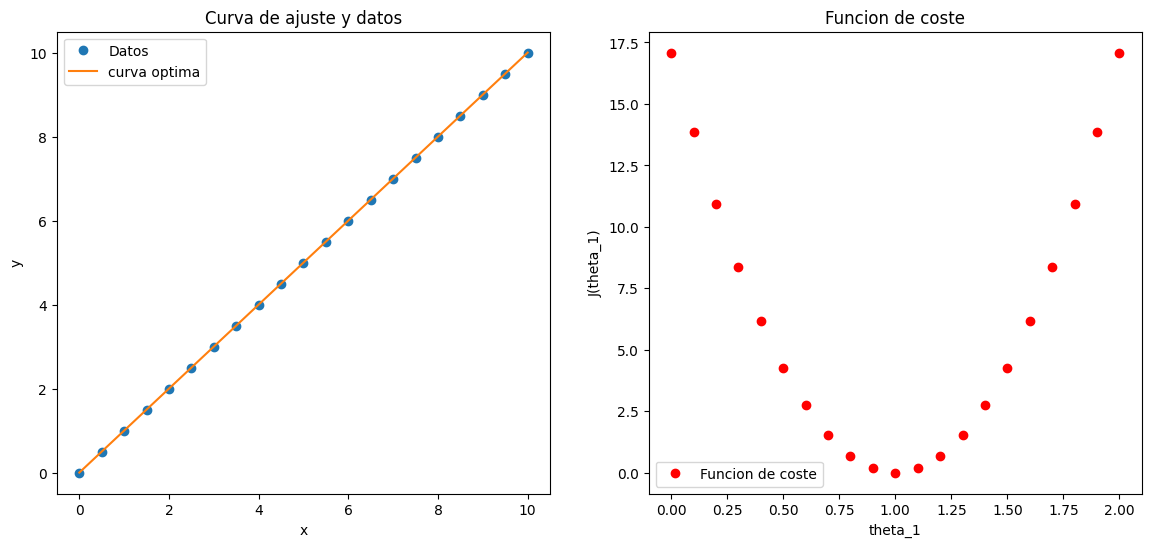

In [ ]:
# @title
from matplotlib import legend
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Construya un DataFrame de pandas con un conjunto de datos lineales simples.

x = np.linspace(0,10,21)
y = np.linspace(0,10,21)

df = pd.DataFrame({'x': x, 'y': y})

# 2) Defina una función que calcule la función de coste cuadrática para un modelo de regresión lineal.

def func_coste(theta0, theta1, df):
    """
    theta0: float - parametro de intercepto con el eje
    theta1: float - parametro de pendiente de la recta
    df: pandas.DataFrame - dataframe con los datos
    """
    m = len(df["x"])
    return np.sum((theta0 + theta1*df["x"] - df["y"])**2)/(2*m)

def h(theta0, theta1, x):
    return theta0 + theta1*x

# 3) Fijando inicialmente  θ0=0 , evalúe y grafique la función de coste para diferentes valores de  θ1 .
#Determine el valor que minimiza la función de coste y grafique la recta obtenida sobre los datos.

theta_1_prueba = np.linspace(0,2,21)

z = []
for i in theta_1_prueba:
    z.append(func_coste(0,i,df))
def minimo_z(z):
    """
    Retorna la posicion en lista del argumento minimo de z
    """
    return np.argmin(z)



plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title("Curva de ajuste y datos")
plt.plot(df["x"], df["y"], 'o' , label="Datos")
plt.plot(df['x'], h(0,theta_1_prueba[minimo_z(z)],df['x']), label = "curva optima")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(1,2,2)
plt.title("Funcion de coste")
plt.plot(theta_1_prueba, z , "ro", label = "Funcion de coste")
plt.xlabel("theta_1")
plt.ylabel("J(theta_1)")
plt.legend()
plt.show()

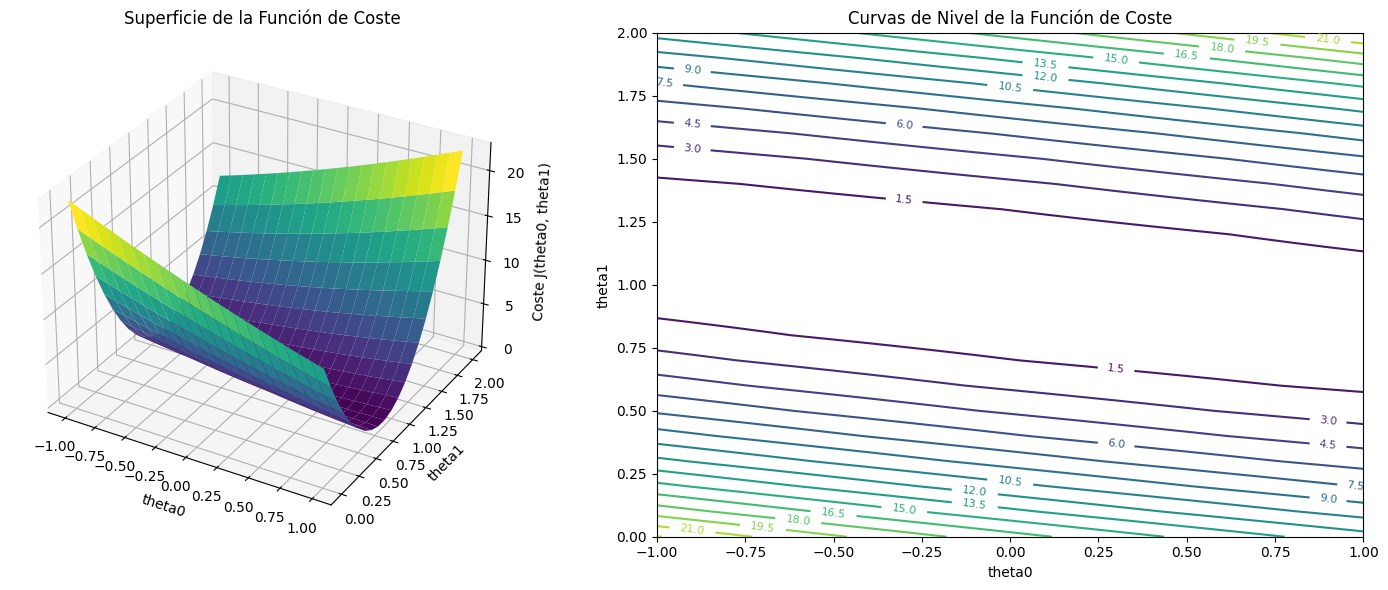

In [ ]:
# @title
theta_1_prueba = np.linspace(0,2,21)
theta_0_prueba = np.linspace(-1,1,21)

theta0_mesh, theta1_mesh = np.meshgrid(theta_0_prueba, theta_1_prueba)

# Calcular la función de coste para cada combinación de theta0 y theta1
# Usamos .ravel() para aplanar las mallas a 1D, pasamos cada par a func_coste,
# y luego volvemos a dar forma (reshape) al resultado a la forma original de la malla.
Z = np.array([func_coste(t0, t1, df) for t0, t1 in zip(theta0_mesh.ravel(), theta1_mesh.ravel())]).reshape(theta0_mesh.shape)

# Graficar la superficie 3D y las curvas de nivel
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 6))

# Gráfico de superficie 3D
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(theta0_mesh, theta1_mesh, Z, cmap='viridis')
ax.set_xlabel('theta0')
ax.set_ylabel('theta1')
ax.set_zlabel('Coste J(theta0, theta1)')
ax.set_title('Superficie de la Función de Coste')

# Gráfico de curvas de nivel
ax2 = fig.add_subplot(122)
contour = ax2.contour(theta0_mesh, theta1_mesh, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=1, fontsize=8)
ax2.set_xlabel('theta0')
ax2.set_ylabel('theta1')
ax2.set_title('Curvas de Nivel de la Función de Coste')

plt.tight_layout()
plt.show()

5) Interprete geométricamente la forma de la función de coste e identifique el mínimo global.

La superficie 3D tiene forma de “cuenco” o paraboloide.
Esto indica que la función es convexa: no hay múltiples mínimos locales complicados.
Las curvas de nivel (la gráfica de la derecha) son elipses.
Esto es clave: cuando las curvas de nivel son elípticas y cerradas, significa que hay un único mínimo global.
A medida que te alejas del centro de las elipses, el coste aumenta.

El mínimo global está en el centro de las elipses más internas (la región más oscura en la gráfica de contornos).
En la superficie 3D, corresponde al punto más bajo del cuenco.

A ojo, parece estar aproximadamente cerca de:

𝜃
0
≈
0.5
,
𝜃
1
≈
1


(Ese es el punto donde las curvas de nivel se cierran más y el valor del coste es mínimo).

6. Repita el procedimiento para un conjunto de datos con ruido y compare los resultados con el caso ideal.

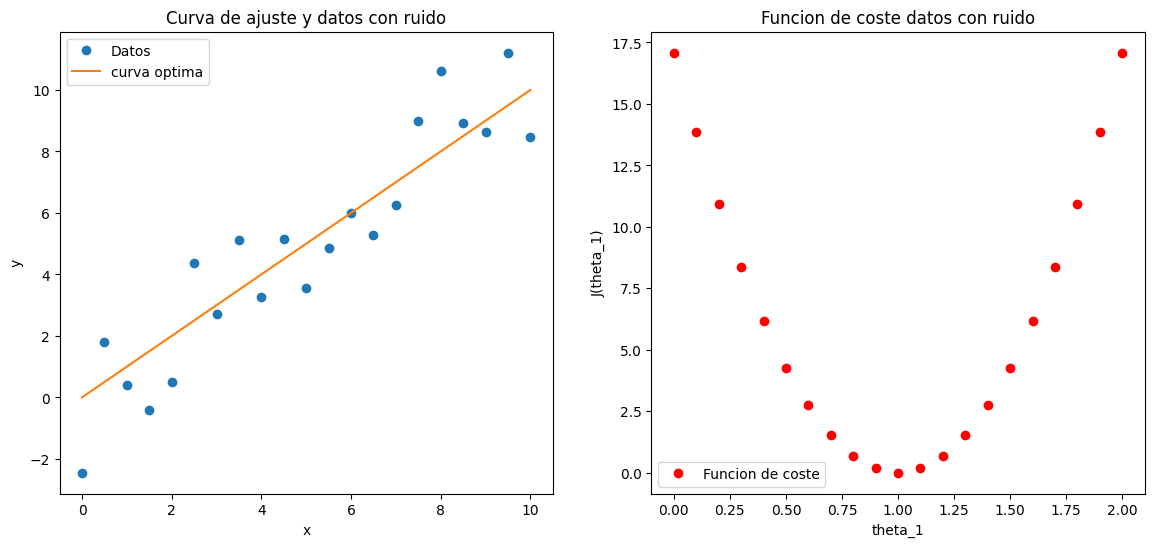

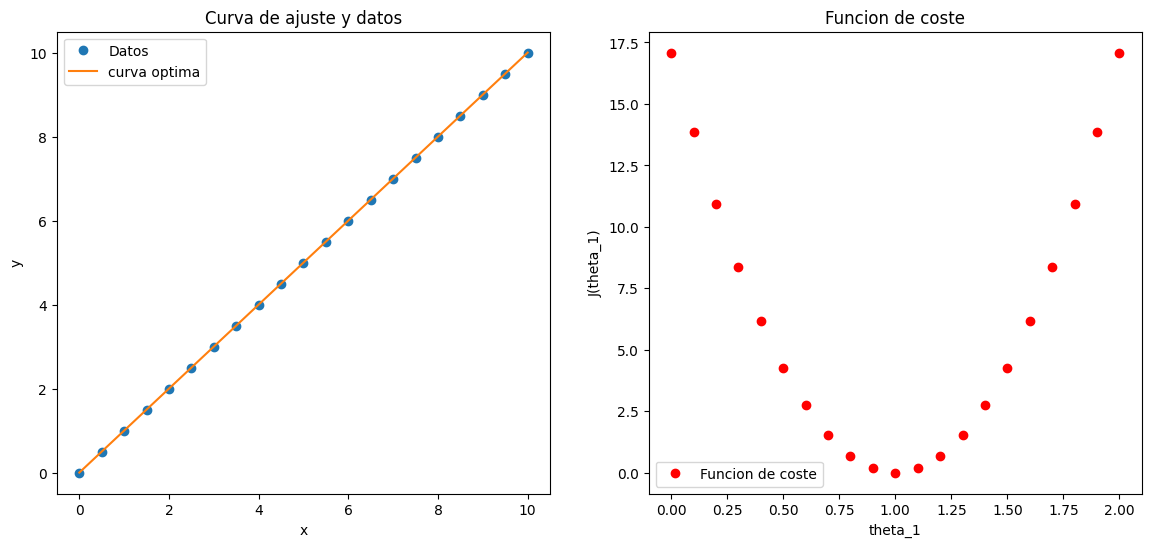

In [ ]:
# @title
#Generación de los datos con ruido
x = np.linspace(0,10,21)
ruido = np.random.normal(loc=0, scale=1, size=len(y))
y_ruidoso = y + ruido

ndf = pd.DataFrame({'x': x, 'y': y_ruidoso})

# primeros graficos para comparar con el caso sin ruido

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title("Curva de ajuste y datos con ruido")
plt.plot(ndf["x"], ndf["y"], 'o' , label="Datos")
plt.plot(ndf['x'], h(0,theta_1_prueba[minimo_z(z)],ndf['x']), label = "curva optima")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(1,2,2)
plt.title("Funcion de coste datos con ruido")
plt.plot(theta_1_prueba, z , "ro", label = "Funcion de coste")
plt.xlabel("theta_1")
plt.ylabel("J(theta_1)")
plt.legend()
plt.show()

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title("Curva de ajuste y datos")
plt.plot(df["x"], df["y"], 'o' , label="Datos")
plt.plot(df['x'], h(0,theta_1_prueba[minimo_z(z)],df['x']), label = "curva optima")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(1,2,2)
plt.title("Funcion de coste")
plt.plot(theta_1_prueba, z , "ro", label = "Funcion de coste")
plt.xlabel("theta_1")
plt.ylabel("J(theta_1)")
plt.legend()
plt.show()

Se puede apreciar que apesar de que los datos tengan ruido, el método de gradiente descendiente sigue siendo una muy buena aproximación variando uncamente valores de theta1.

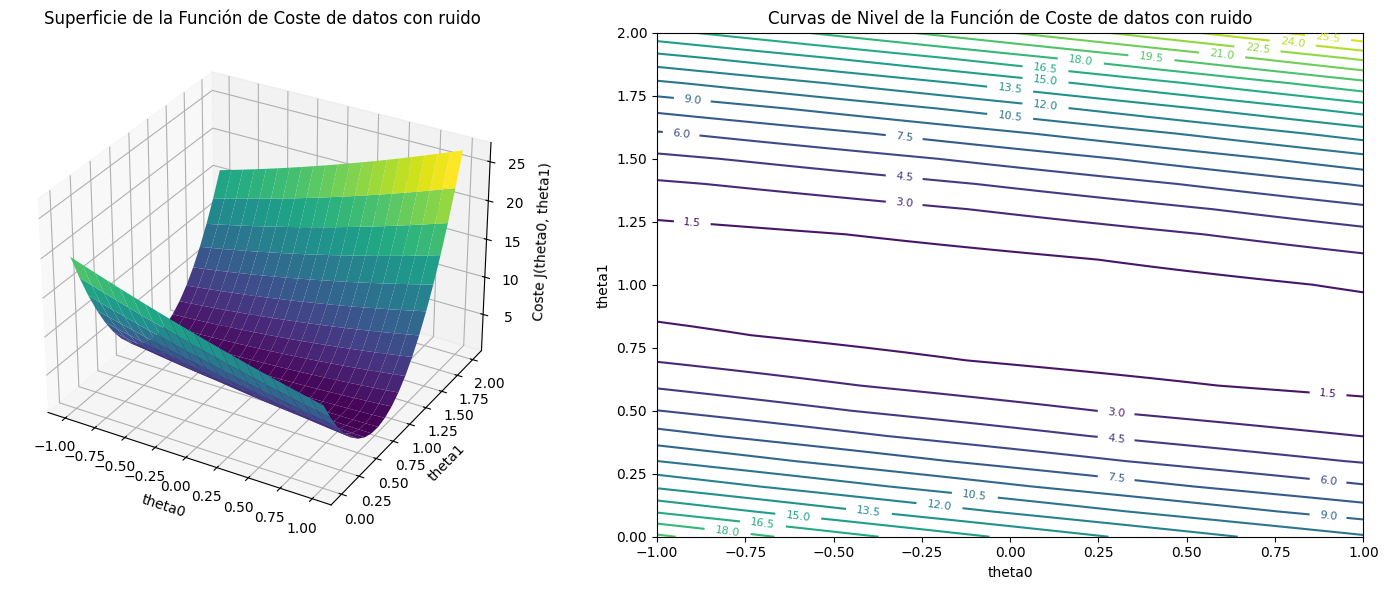

Se puede apreciar también el mismo comportamiendo a cuando los datos
no tenían ruido, por lo que es una muy buena aproximación 


In [ ]:
# @title
theta_1_prueba = np.linspace(0,2,21)
theta_0_prueba = np.linspace(-1,1,21)

theta0_mesh, theta1_mesh = np.meshgrid(theta_0_prueba, theta_1_prueba)

Z = np.array([func_coste(t0, t1, ndf) for t0, t1 in zip(theta0_mesh.ravel(), theta1_mesh.ravel())]).reshape(theta0_mesh.shape)

# Graficar la superficie 3D y las curvas de nivel
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 6))

# Gráfico de superficie 3D
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(theta0_mesh, theta1_mesh, Z, cmap='viridis')
ax.set_xlabel('theta0')
ax.set_ylabel('theta1')
ax.set_zlabel('Coste J(theta0, theta1)')
ax.set_title('Superficie de la Función de Coste de datos con ruido')

# Gráfico de curvas de nivel
ax2 = fig.add_subplot(122)
contour = ax2.contour(theta0_mesh, theta1_mesh, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=1, fontsize=8)
ax2.set_xlabel('theta0')
ax2.set_ylabel('theta1')
ax2.set_title('Curvas de Nivel de la Función de Coste de datos con ruido')

plt.tight_layout()
plt.show()

print("""Se puede apreciar también el mismo comportamiendo a cuando los datos
no tenían ruido, por lo que es una muy buena aproximación """)

7. Analice el efecto de introducir un valor atípico en el conjunto de datos. Discuta cómo cambia la solución y qué limitaciones presenta la función de coste cuadrática.

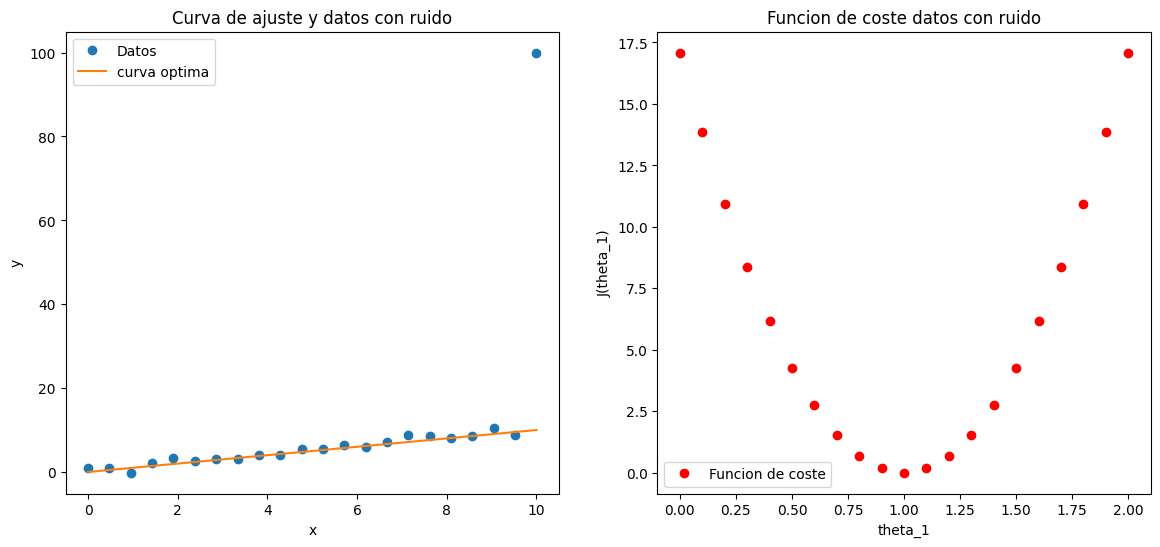

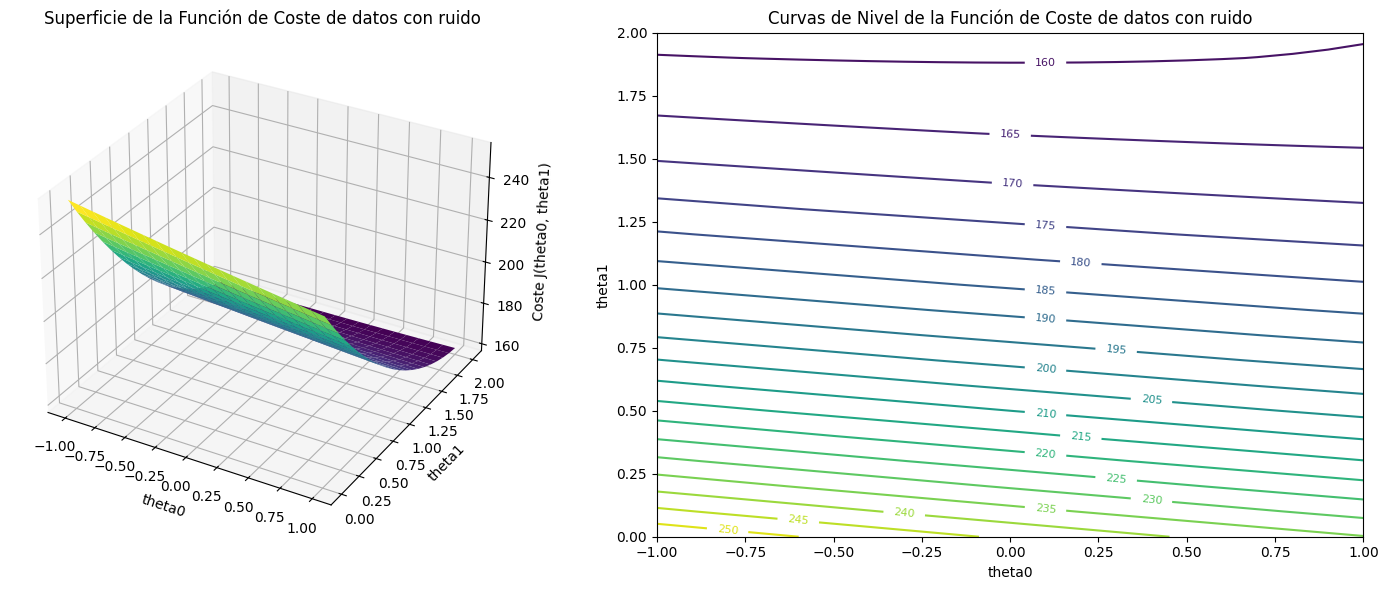

In [ ]:
# @title

#Generación de los datos con ruido
x = np.linspace(0,10,22)
ruido = np.random.normal(loc=0, scale=1, size=len(y))
y_ruidoso = y + ruido
y_atipico = y_ruidoso.copy()
y_atipico = np.append(y_atipico, 100)



ndf2 = pd.DataFrame({'x': x, 'y': y_atipico})

# primeros graficos para comparar con el caso sin ruido

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title("Curva de ajuste y datos con ruido")
plt.plot(ndf2["x"], ndf2["y"], 'o' , label="Datos")
plt.plot(ndf2['x'], h(0,theta_1_prueba[minimo_z(z)],ndf2['x']), label = "curva optima")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(1,2,2)
plt.title("Funcion de coste datos con ruido")
plt.plot(theta_1_prueba, z , "ro", label = "Funcion de coste")
plt.xlabel("theta_1")
plt.ylabel("J(theta_1)")
plt.legend()
plt.show()


Z = np.array([func_coste(t0, t1, ndf2) for t0, t1 in zip(theta0_mesh.ravel(), theta1_mesh.ravel())]).reshape(theta0_mesh.shape)

# Graficar la superficie 3D y las curvas de nivel
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 6))

# Gráfico de superficie 3D
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(theta0_mesh, theta1_mesh, Z, cmap='viridis')
ax.set_xlabel('theta0')
ax.set_ylabel('theta1')
ax.set_zlabel('Coste J(theta0, theta1)')
ax.set_title('Superficie de la Función de Coste de datos con ruido')

# Gráfico de curvas de nivel
ax2 = fig.add_subplot(122)
contour = ax2.contour(theta0_mesh, theta1_mesh, Z, levels=20, cmap='viridis')
ax2.clabel(contour, inline=1, fontsize=8)
ax2.set_xlabel('theta0')
ax2.set_ylabel('theta1')
ax2.set_title('Curvas de Nivel de la Función de Coste de datos con ruido')

plt.tight_layout()
plt.show()

Al introducir un valor atípico en el conjunto de datos, la recta de ajuste se ve significativamente afectada, desviándose para intentar ajustarse a ese punto extremo. Como resultado, el modelo pierde representatividad sobre la mayoría de los datos.

En la función de coste, el mínimo global se desplaza y el valor mínimo aumenta. Aunque la función sigue siendo convexa, su forma se ve influenciada por el outlier.

Esto ocurre porque la función de coste cuadrática (MSE) penaliza los errores grandes al cuadrado, haciendo que los valores atípicos tengan un impacto desproporcionado en la solución.

Como limitación, el MSE no es robusto frente a outliers, por lo que en presencia de estos puede producir ajustes poco representativos. Alternativas como el error absoluto (MAE) o funciones robustas como Huber reducen este problema.

## 8. Compare el ajuste obtenido con un modelo lineal sobre un conjunto de datos no lineales. Discuta si minimizar la función de coste garantiza que el modelo sea adecuado.


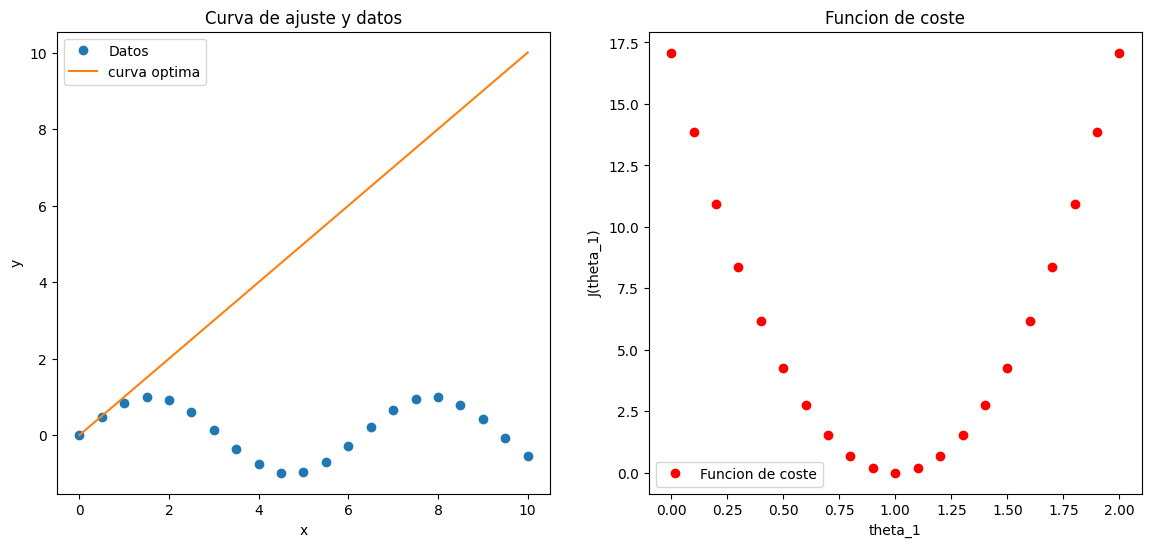


Al aplicar un modelo lineal a un conjunto de datos no lineales, se observa que la recta de ajuste no logra capturar la forma real de los datos,
 presentando errores sistemáticos a lo largo del dominio. En la gráfica, los datos siguen una tendencia curva, mientras que el modelo lineal solo 
 puede aproximar con una recta, lo que genera un mal ajuste.
Aunque la función de coste presenta un mínimo bien definido y se puede minimizar correctamente, esto no garantiza que el modelo sea adecuado. 
El proceso de optimización únicamente encuentra los mejores parámetros dentro de la familia de modelos elegida (en este caso, funciones lineales), 
pero no corrige una mala elección del modelo.
En conclusión, minimizar la función de coste asegura el mejor ajuste posible para ese modelo específico, pero no garantiza que el modelo represente
 correctamente los datos si la relación subyacente es no lineal.




In [ ]:
# @title
x = np.linspace(0,10,21)
y = np.sin(x)

df3 = pd.DataFrame({'x': x, 'y': y})

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title("Curva de ajuste y datos")
plt.plot(df3["x"], df3["y"], 'o' , label="Datos")
plt.plot(df3['x'], h(0,theta_1_prueba[minimo_z(z)],df3['x']), label = "curva optima")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(1,2,2)
plt.title("Funcion de coste")
plt.plot(theta_1_prueba, z , "ro", label = "Funcion de coste")
plt.xlabel("theta_1")
plt.ylabel("J(theta_1)")
plt.legend()
plt.show()

print("""
Al aplicar un modelo lineal a un conjunto de datos no lineales, se observa que la recta de ajuste no logra capturar la forma real de los datos,
 presentando errores sistemáticos a lo largo del dominio. En la gráfica, los datos siguen una tendencia curva, mientras que el modelo lineal solo
 puede aproximar con una recta, lo que genera un mal ajuste.
Aunque la función de coste presenta un mínimo bien definido y se puede minimizar correctamente, esto no garantiza que el modelo sea adecuado.
El proceso de optimización únicamente encuentra los mejores parámetros dentro de la familia de modelos elegida (en este caso, funciones lineales),
pero no corrige una mala elección del modelo.
En conclusión, minimizar la función de coste asegura el mejor ajuste posible para ese modelo específico, pero no garantiza que el modelo represente
 correctamente los datos si la relación subyacente es no lineal.

""")

## 9. Obtenga la expresión teórica de la función de coste en el caso con un parámetro y con dos parámetros, e interprete el significado de sus mínimos.

## 🧮 Deducción de la función de coste

### 🔹 Caso 1: Modelo con un parámetro

Sea un modelo lineal sin intercepto:

$$
\hat{y}_i = \theta x_i
$$

La función de coste (error cuadrático medio) es:

$$
J(\theta) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \theta x_i)^2
$$

Derivando respecto a $\theta$:

$$
\frac{dJ}{d\theta} = \frac{1}{N} \sum_{i=1}^{N} 2(y_i - \theta x_i)(-x_i)
$$

$$
= -\frac{2}{N} \sum_{i=1}^{N} x_i (y_i - \theta x_i)
$$

Para encontrar el mínimo:

$$
\frac{dJ}{d\theta} = 0
$$

$$
\sum_{i=1}^{N} x_i y_i - \theta \sum_{i=1}^{N} x_i^2 = 0
$$

Despejando $\theta$:

$$
\theta = \frac{\sum x_i y_i}{\sum x_i^2}
$$

---

### 🔹 Caso 2: Modelo con dos parámetros

Sea el modelo:

$$
\hat{y}_i = \theta_0 + \theta_1 x_i
$$

La función de coste es:

$$
J(\theta_0, \theta_1) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \theta_0 - \theta_1 x_i)^2
$$

Derivadas parciales:

$$
\frac{\partial J}{\partial \theta_0} = -\frac{2}{N} \sum_{i=1}^{N} (y_i - \theta_0 - \theta_1 x_i)
$$

$$
\frac{\partial J}{\partial \theta_1} = -\frac{2}{N} \sum_{i=1}^{N} x_i (y_i - \theta_0 - \theta_1 x_i)
$$

Igualando a cero:

$$
\sum (y_i - \theta_0 - \theta_1 x_i) = 0
$$

$$
\sum x_i (y_i - \theta_0 - \theta_1 x_i) = 0
$$

Resolviendo, se obtienen las ecuaciones normales:

$$
\theta_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}
$$

$$
\theta_0 = \bar{y} - \theta_1 \bar{x}
$$

---

## 📌 Interpretación de los mínimos

El mínimo de la función de coste representa los parámetros que mejor ajustan el modelo a los datos, minimizando el error cuadrático promedio.

- En el caso de un parámetro, el mínimo determina la mejor pendiente cuando la recta pasa por el origen.
- En el caso de dos parámetros, el mínimo define la recta óptima (pendiente e intercepto).

Debido a que la función de coste es convexa, este mínimo es único y corresponde al punto más bajo de la parábola (1D) o del paraboloide (2D).

Sin embargo, este mínimo solo garantiza el mejor ajuste dentro del modelo elegido, no que el modelo sea adecuado para describir la relación real de los datos.

## 10.
 Construya un algoritmo en el que emplee el gradiente descendente para determinar el mínimo de una función. Determine dicho mínimo con un error $\epsilon$ de $10^{-4}$. Pruebe su algoritmo para

$$
f(x)=(x-4)^2
$$

y al menos tres valores diferentes de $\alpha$.

In [ ]:
import sympy as sym
import numpy as np # Necesario para lambdify con 'numpy'

def grad_desc(f_sym, x_sym, initial_x, alpha, epsilon=1e-4, max_iterations=10000):
  """
  Implementa el algoritmo de gradiente descendente para encontrar el mínimo de una función.

  Args:
      f_sym (sympy.Expr): La expresión simbólica de la función a minimizar.
      x_sym (sympy.Symbol): La variable simbólica de la función.
      initial_x (float): El valor inicial de x.
      alpha (float): La tasa de aprendizaje.
      epsilon (float): El umbral de convergencia.
      max_iterations (int): El número máximo de iteraciones.

  Returns:
      tuple: Una tupla que contiene el valor mínimo encontrado y el número de iteraciones.
  """
  # Calcular la derivada simbólica
  df_sym = sym.diff(f_sym, x_sym)

  # Convertir la derivada simbólica a una función numérica
  df_num = sym.lambdify(x_sym, df_sym, 'numpy')

  x = initial_x
  for i in range(max_iterations):
      # Evaluar la derivada numérica en el punto actual
      grad_f = df_num(x)

      # Actualiza x en la dirección opuesta al gradiente
      new_x = x - alpha * grad_f

      # Verifica la condición de convergencia
      if abs(new_x - x) < epsilon:
          return new_x, i + 1

      x = new_x

  return x, max_iterations # Retorna el último valor si se alcanza el máximo de iteraciones

# Definir la variable simbólica
x = sym.symbols('x')

# Definir la función a minimizar de forma simbólica: f(x) = (x-4)^2
f_sym = (x-4)**2

print("--- Probando con diferentes valores de alfa ---")

# Prueba con alpha = 0.1
alpha1 = 0.1
min_x1, iters1 = grad_desc(f_sym, x, initial_x=0, alpha=alpha1)
print(f"Para alpha = {alpha1}: Mínimo encontrado en x = {min_x1:.4f} en {iters1} iteraciones.")

# Prueba con alpha = 0.01
alpha2 = 0.01
min_x2, iters2 = grad_desc(f_sym, x, initial_x=0, alpha=alpha2)
print(f"Para alpha = {alpha2}: Mínimo encontrado en x = {min_x2:.4f} en {iters2} iteraciones.")

# Prueba con alpha = 0.5 (puede ser inestable si es muy grande)
alpha3 = 0.5
min_x3, iters3 = grad_desc(f_sym, x, initial_x=0, alpha=alpha3)
print(f"Para alpha = {alpha3}: Mínimo encontrado en x = {min_x3:.4f} en {iters3} iteraciones.")

# Prueba con alpha = 0.9 (muy grande, podría oscilar o divergir)
alpha4 = 0.9
min_x4, iters4 = grad_desc(f_sym, x, initial_x=0, alpha=alpha4)
print(f"Para alpha = {alpha4}: Mínimo encontrado en x = {min_x4:.4f} en {iters4} iteraciones.")

--- Probando con diferentes valores de alfa ---
Para alpha = 0.1: Mínimo encontrado en x = 3.9997 en 42 iteraciones.
Para alpha = 0.01: Mínimo encontrado en x = 3.9951 en 332 iteraciones.
Para alpha = 0.5: Mínimo encontrado en x = 4.0000 en 2 iteraciones.
Para alpha = 0.9: Mínimo encontrado en x = 4.0000 en 52 iteraciones.


11. Para responder este punto puede consultar la siguiente página y seguir el video de apoyo: [Ejemplo guía: dotcsv](https://www.youtube.com/watch?v=-_A_AAxqzCg)

Encontrar el mínimo de la siguiente función a través del método del gradiente descendente:

\begin{equation}
F(x,y)=\sin\left(\frac{1}{2}x^2-\frac{1}{4}y^2+3\right)\cos(2x+1-e^y)
\end{equation}

- Para ello, realice una gráfica de la función en 3D y un mapa de contorno de la función.
- Determine el valor mínimo de la función con el método del gradiente descendente.

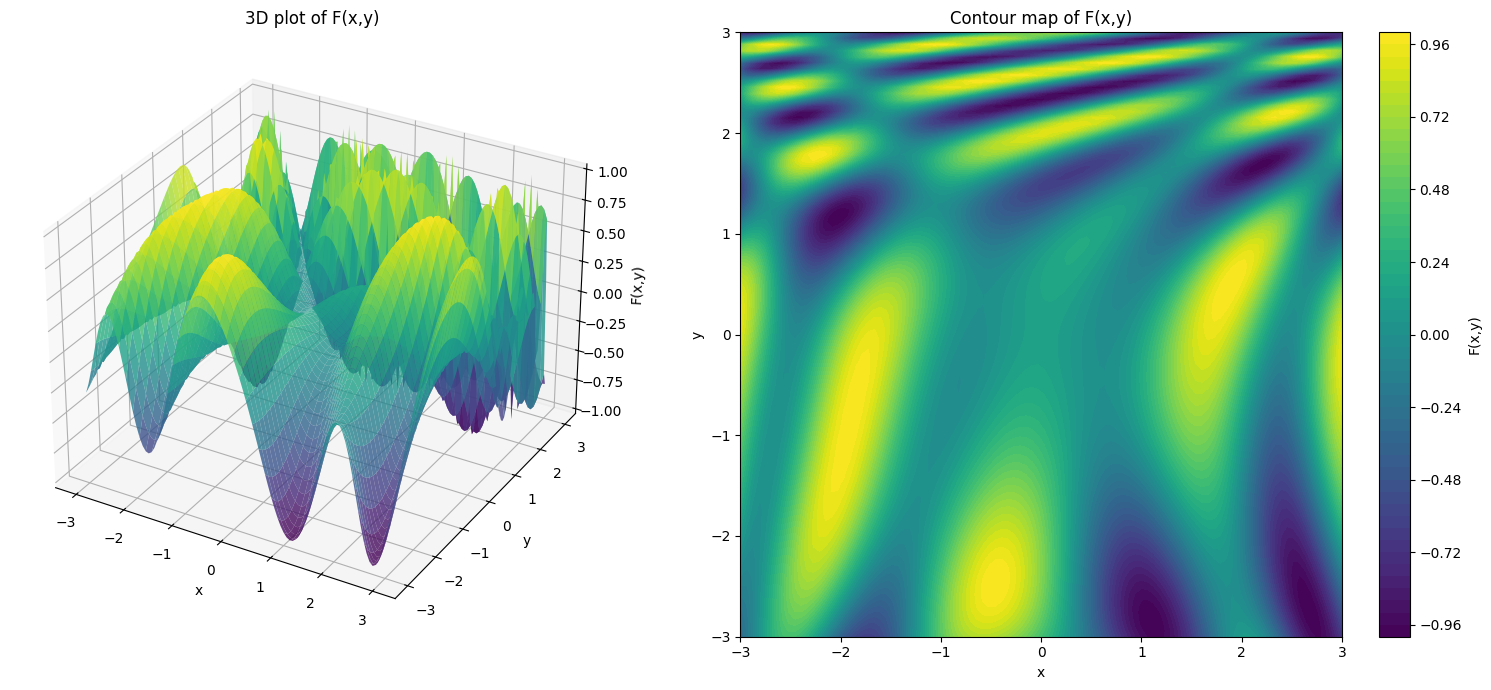


--- Gradient Descent Results ---
Initial point: (1.0, -1.0)
Learning rate (alpha): 0.01
Minimum found at: x = 1.0973, y = -2.8461
Value of F(x,y) at minimum: -1.0000
Iterations: 560


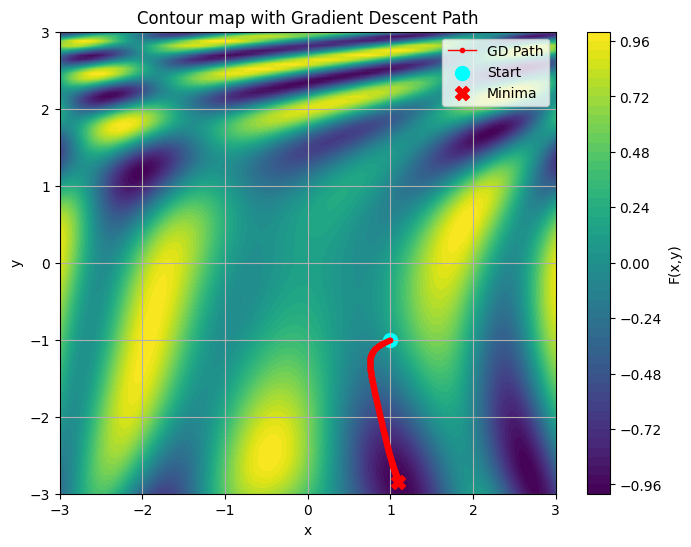

In [ ]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Define the function symbolically
x_sym, y_sym = sym.symbols('x y')
f_sym = sym.sin(sym.Rational(1, 2)*x_sym**2 - sym.Rational(1, 4)*y_sym**2 + 3) * sym.cos(2*x_sym + 1 - sym.exp(y_sym))

# 2. Calculate partial derivatives
df_dx_sym = sym.diff(f_sym, x_sym)
df_dy_sym = sym.diff(f_sym, y_sym)

# Convert symbolic functions to numerical functions
f_num = sym.lambdify((x_sym, y_sym), f_sym, 'numpy')
df_dx_num = sym.lambdify((x_sym, y_sym), df_dx_sym, 'numpy')
df_dy_num = sym.lambdify((x_sym, y_sym), df_dy_sym, 'numpy')

# 3. Plotting the function in 3D and its contour map

# Generate data for plotting
x_vals = np.linspace(-3, 3, 100)
y_vals = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f_num(X, Y)

fig = plt.figure(figsize=(16, 7))

# 3D plot
ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('F(x,y)')
ax.set_title('3D plot of F(x,y)')

# Contour plot
ax_contour = fig.add_subplot(122)
contour = ax_contour.contourf(X, Y, Z, levels=50, cmap='viridis')
fig.colorbar(contour, ax=ax_contour, label='F(x,y)')
ax_contour.set_xlabel('x')
ax_contour.set_ylabel('y')
ax_contour.set_title('Contour map of F(x,y)')

plt.tight_layout()
plt.show()

# 4. Implement Gradient Descent for 2D function
def grad_desc_2d(f, df_dx, df_dy, initial_point, alpha, epsilon=1e-4, max_iterations=100000):
    """
    Implementa el algoritmo de gradiente descendente para encontrar el mínimo de una función 2D.

    Args:
        f (function): La función numérica a minimizar (acepta x, y).
        df_dx (function): La derivada parcial de f con respecto a x.
        df_dy (function): La derivada parcial de f con respecto a y.
        initial_point (tuple): Un tuple (x0, y0) con el punto inicial.
        alpha (float): La tasa de aprendizaje.
        epsilon (float): El umbral de convergencia para el cambio en x y y.
        max_iterations (int): El número máximo de iteraciones.

    Returns:
        tuple: Una tupla (min_x, min_y, iterations) con el valor mínimo encontrado y el número de iteraciones.
    """
    x, y = initial_point
    path = [(x, y)] # To store the path for visualization

    for i in range(max_iterations):
        grad_x = df_dx(x, y)
        grad_y = df_dy(x, y)

        new_x = x - alpha * grad_x
        new_y = y - alpha * grad_y

        if np.sqrt((new_x - x)**2 + (new_y - y)**2) < epsilon:
            return new_x, new_y, i + 1, path

        x, y = new_x, new_y
        path.append((x, y))

    return x, y, max_iterations, path

# Determine initial point based on visual inspection of the contour plot
# A good starting point for this function might be around (-1, -1) or (1, -1) as it shows local minima.
initial_x, initial_y = 1.0, -1.0 # Starting point can be adjusted
learning_rate = 0.01 # Learning rate can be adjusted

min_x, min_y, iters, path = grad_desc_2d(f_num, df_dx_num, df_dy_num,
                                         (initial_x, initial_y), learning_rate)

print(f"\n--- Gradient Descent Results ---")
print(f"Initial point: ({initial_x}, {initial_y})")
print(f"Learning rate (alpha): {learning_rate}")
print(f"Minimum found at: x = {min_x:.4f}, y = {min_y:.4f}")
print(f"Value of F(x,y) at minimum: {f_num(min_x, min_y):.4f}")
print(f"Iterations: {iters}")

# Optional: Plot the path of gradient descent on the contour map
path = np.array(path)
plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(contour, label='F(x,y)')
plt.plot(path[:, 0], path[:, 1], 'r-o', markersize=3, linewidth=1, label='GD Path')
plt.scatter(initial_x, initial_y, color='cyan', marker='o', s=100, label='Start')
plt.scatter(min_x, min_y, color='red', marker='X', s=100, label='Minima')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Contour map with Gradient Descent Path')
plt.legend()
plt.grid(True)
plt.show()


12. Empleando los siguientes datos:

```python
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2*X + 0.02*np.random.random(100)
```

y las herramientas desarrolladas en los apartados anteriores, construya un algorítmo que permita determinar una regresión lineal.

11. Compare su resultado empleando la libreria linearRegresion() de sklearn.

Gradient Descent converged in 925 iterations.

--- Gradient Descent Results ---
Optimal theta0 (GD): 0.2119
Optimal theta1 (GD): 0.1978


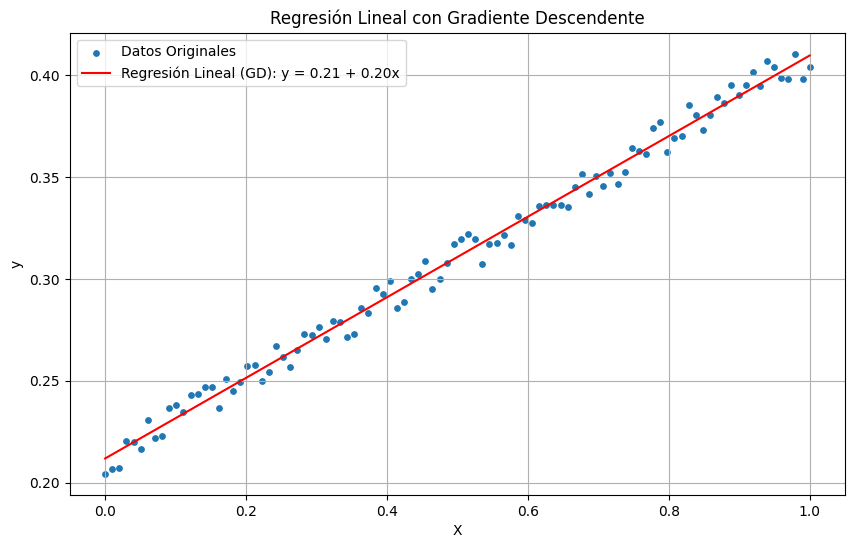


--- scikit-learn LinearRegression Results ---
Optimal theta0 (sklearn): 0.2118
Optimal theta1 (sklearn): 0.1979


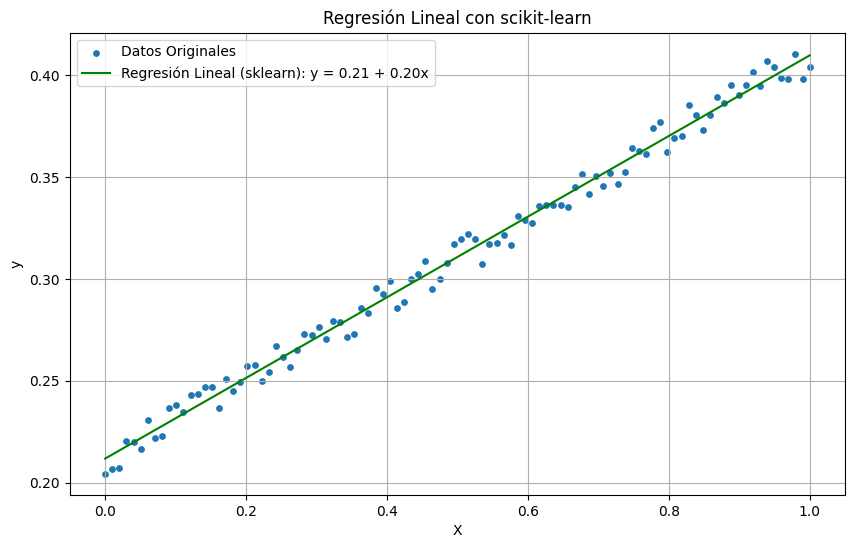

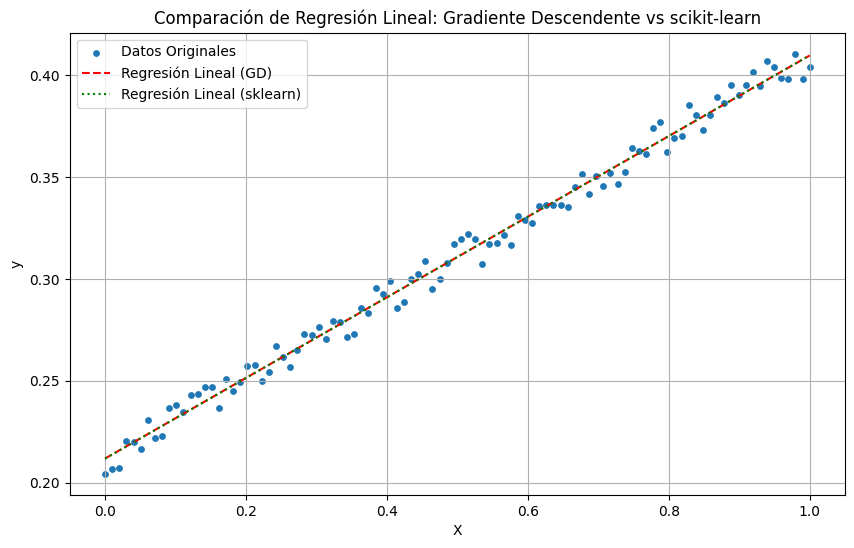


--- Análisis de la Comparación ---
Ambos métodos (Gradiente Descendente y scikit-learn) producen resultados muy similares, 
lo cual es esperado ya que ambos buscan minimizar la misma función de coste (MSE) para la regresión lineal. 
Las diferencias mínimas pueden deberse a la convergencia numérica del gradiente descendente (tasa de aprendizaje, 
número de iteraciones, criterio de parada) y a la precisión del algoritmo de mínimos cuadrados ordinarios usado por scikit-learn 
(que encuentra la solución analítica exacta).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 12. Empleando los siguientes datos:
X = np.linspace(0, 1, 100)
y = 0.2 + 0.2 * X + 0.02 * np.random.random(100)

# Combine X and y into a DataFrame for compatibility with func_coste
data_df = pd.DataFrame({'x': X, 'y': y})

# Reuse the hypothesis function from earlier
def h(theta0, theta1, x):
    return theta0 + theta1 * x

# Reuse the cost function from earlier
def func_coste(theta0, theta1, df):
    m = len(df["x"])
    return np.sum((theta0 + theta1 * df["x"] - df["y"])**2) / (2 * m)

# Gradient Descent Algorithm for Linear Regression
def gradient_descent_linear_regression(X, y, initial_theta0, initial_theta1, alpha, iterations, epsilon=1e-6):
    m = len(y)
    theta0 = initial_theta0
    theta1 = initial_theta1
    cost_history = []
    theta0_history = []
    theta1_history = []

    for i in range(iterations):
        predictions = h(theta0, theta1, X)
        errors = predictions - y

        # Partial derivatives
        d_theta0 = (1 / m) * np.sum(errors)
        d_theta1 = (1 / m) * np.sum(errors * X)

        # Update parameters
        new_theta0 = theta0 - alpha * d_theta0
        new_theta1 = theta1 - alpha * d_theta1

        # Store history
        theta0_history.append(theta0)
        theta1_history.append(theta1)
        cost_history.append(func_coste(theta0, theta1, data_df))

        # Check for convergence
        if np.sqrt((new_theta0 - theta0)**2 + (new_theta1 - theta1)**2) < epsilon:
            theta0 = new_theta0
            theta1 = new_theta1
            break

        theta0 = new_theta0
        theta1 = new_theta1

    print(f"Gradient Descent converged in {i+1} iterations.")
    return theta0, theta1, cost_history, theta0_history, theta1_history

# Initial parameters for Gradient Descent
initial_theta0_gd = 0.0
initial_theta1_gd = 0.0
alpha_gd = 0.1 # Learning rate
iterations_gd = 10000

# Run Gradient Descent
theta0_gd, theta1_gd, cost_hist, theta0_hist, theta1_hist = \
    gradient_descent_linear_regression(X, y, initial_theta0_gd, initial_theta1_gd, alpha_gd, iterations_gd)

print(f"\n--- Gradient Descent Results ---")
print(f"Optimal theta0 (GD): {theta0_gd:.4f}")
print(f"Optimal theta1 (GD): {theta1_gd:.4f}")

# Plotting GD results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Datos Originales', s=15)
plt.plot(X, h(theta0_gd, theta1_gd, X), color='red', label=f'Regresión Lineal (GD): y = {theta0_gd:.2f} + {theta1_gd:.2f}x')
plt.title('Regresión Lineal con Gradiente Descendente')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# 11. Compare su resultado empleando la libreria linearRegresion() de sklearn.

# Using sklearn's LinearRegression
sklearn_model = LinearRegression()
sklearn_model.fit(X.reshape(-1, 1), y)

theta0_sklearn = sklearn_model.intercept_
theta1_sklearn = sklearn_model.coef_[0]

print(f"\n--- scikit-learn LinearRegression Results ---")
print(f"Optimal theta0 (sklearn): {theta0_sklearn:.4f}")
print(f"Optimal theta1 (sklearn): {theta1_sklearn:.4f}")

# Plotting sklearn results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Datos Originales', s=15)
plt.plot(X, h(theta0_sklearn, theta1_sklearn, X), color='green', label=f'Regresión Lineal (sklearn): y = {theta0_sklearn:.2f} + {theta1_sklearn:.2f}x')
plt.title('Regresión Lineal con scikit-learn')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# Comparison plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Datos Originales', s=15)
plt.plot(X, h(theta0_gd, theta1_gd, X), color='red', linestyle='--', label='Regresión Lineal (GD)')
plt.plot(X, h(theta0_sklearn, theta1_sklearn, X), color='green', linestyle=':', label='Regresión Lineal (sklearn)')
plt.title('Comparación de Regresión Lineal: Gradiente Descendente vs scikit-learn')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Análisis de la Comparación ---")
print("""Ambos métodos (Gradiente Descendente y scikit-learn) producen resultados muy similares,
lo cual es esperado ya que ambos buscan minimizar la misma función de coste (MSE) para la regresión lineal.
Las diferencias mínimas pueden deberse a la convergencia numérica del gradiente descendente (tasa de aprendizaje,
número de iteraciones, criterio de parada) y a la precisión del algoritmo de mínimos cuadrados ordinarios usado por scikit-learn
(que encuentra la solución analítica exacta).""")
